# Kv2.1 L403A mutation-site distance analysis

Default ensemble subset: **allOk3 + structural/interface QC** (`all_ok_3_structural_interface_qc`; corrected 3 Å convergence, G377 tetramer-integrity filtering, and a 27 Å pore–VSD interface cutoff).

This notebook focuses on experimental/paper residue L403A (model/CSV L405A) and tests whether the mutation shifts the intracellular helix/gate geometry. All visible aliases use experimental numbering; WT (8SD3) and L403A (8SDA) experimental Cα distances are overlaid.


In [45]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
repo_root = Path.cwd() if (Path.cwd()/"shared").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
from shared.plotting import KV21_PALETTE, plot_split_ensemble_with_experimentals, plot_protocol_split_with_experimentals, apply_kv21_style
import importlib, shared.dataset_selection as shared_dataset_selection
importlib.reload(shared_dataset_selection)
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
apply_kv21_style()


In [46]:
DATASET_SELECTION = 'all_ok_3_structural_interface_qc'  # Persisted convergence, tetramer, and interface QC.
data = repo_root / 'kv21' / 'dataDistances'
DATASET_PATHS = {
    'WT masked': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_wt_maskedAF2_distances_all.csv', 'Kv21', 'WT', 'masked'),
    'L403A masked': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_l403a_maskedAF2_distances_all.csv', 'Kv21', 'L403A', 'masked'),
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_wt_vanillaAF2_distances_all.csv', 'Kv21', 'WT', 'vanilla'),
    'L403A vanilla': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_l403a_vanillaAF2_distances_all.csv', 'Kv21', 'L403A', 'vanilla'),
}
DATASET_PATHS
df_wt_masked=load_selected_distance_csv('WT masked',DATASET_PATHS['WT masked'],DATASET_SELECTION); df_l403a_masked=load_selected_distance_csv('L403A masked',DATASET_PATHS['L403A masked'],DATASET_SELECTION)
df_wt_vanilla=load_selected_distance_csv('WT vanilla',DATASET_PATHS['WT vanilla'],DATASET_SELECTION); df_l403a_vanilla=load_selected_distance_csv('L403A vanilla',DATASET_PATHS['L403A vanilla'],DATASET_SELECTION)
print({k:v.shape for k,v in [("WT masked",df_wt_masked),("L403A masked",df_l403a_masked)]})


WT masked: requested=all_ok_3_structural_interface_qc; actual=all_ok_3_structural_interface_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_qc.csv
L403A masked: requested=all_ok_3_structural_interface_qc; actual=all_ok_3_structural_interface_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_l403a_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_qc.csv
WT vanilla: requested=all_ok_3_structural_interface_qc; actual=all_ok_3_structural_interface_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_qc.csv
L403A vanilla: requested=all_ok_3_structural_interface_qc; actual=all_ok_3_structural_interface_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_l403a_vanillaAF2_distances_all_ok_rmsd_3A_

In [47]:
# Visible aliases use experimental numbering; values are read from unchanged model/CSV columns (+2).
aliases={
 "A_A402-B_A402":"CA_CA_A_ALA404_CA-B_ALA404_CA", "A_A402-C_A402":"CA_CA_A_ALA404_CA-C_ALA404_CA", "A_A402-D_A402":"CA_CA_A_ALA404_CA-D_ALA404_CA",
 "B_A402-C_A402":"CA_CA_B_ALA404_CA-C_ALA404_CA", "B_A402-D_A402":"CA_CA_B_ALA404_CA-D_ALA404_CA", "C_A402-D_A402":"CA_CA_C_ALA404_CA-D_ALA404_CA",
 "A_F236-A_R289":"CA_CA_A_ARG291_CA-A_PHE238_CA", "A_F236-A_R308":"CA_CA_A_ARG310_CA-A_PHE238_CA",
}
aliases={a:c for a,c in aliases.items() if c in df_wt_masked.columns and c in df_l403a_masked.columns}
print("Available mutation-site columns:", list(aliases))
print('Mutation-site distributions are plotted below after coordinate-derived experimental distances are loaded.')


Available mutation-site columns: ['A_A402-B_A402', 'A_A402-C_A402', 'A_A402-D_A402', 'B_A402-C_A402', 'B_A402-D_A402', 'C_A402-D_A402', 'A_F236-A_R289', 'A_F236-A_R308']
Mutation-site distributions are plotted below after coordinate-derived experimental distances are loaded.


## Vanilla comparison and experimental shift ranking


Vanilla mutation-site distributions are included in the experimental comparison section below.


,distance,WT_8SD3,L403A_8SDA,shift_A,abs_shift_A
2,A_A402-D_A402,14.815,8.202,-6.613,6.613
3,B_A402-C_A402,14.808,10.117,-4.691,4.691
5,C_A402-D_A402,10.470,7.248,-3.222,3.222
1,A_A402-C_A402,10.465,12.553,2.088,2.088
4,B_A402-D_A402,10.480,12.460,1.980,1.980
6,A_F236-A_R289,25.412,24.752,-0.660,0.660
7,A_F236-A_R308,13.004,13.550,0.546,0.546
0,A_A402-B_A402,10.477,10.159,-0.318,0.318


Text(0.5, 1.0, 'Kv2.1 | 8SD3 WT vs 8SDA L403A | experimental shifts')

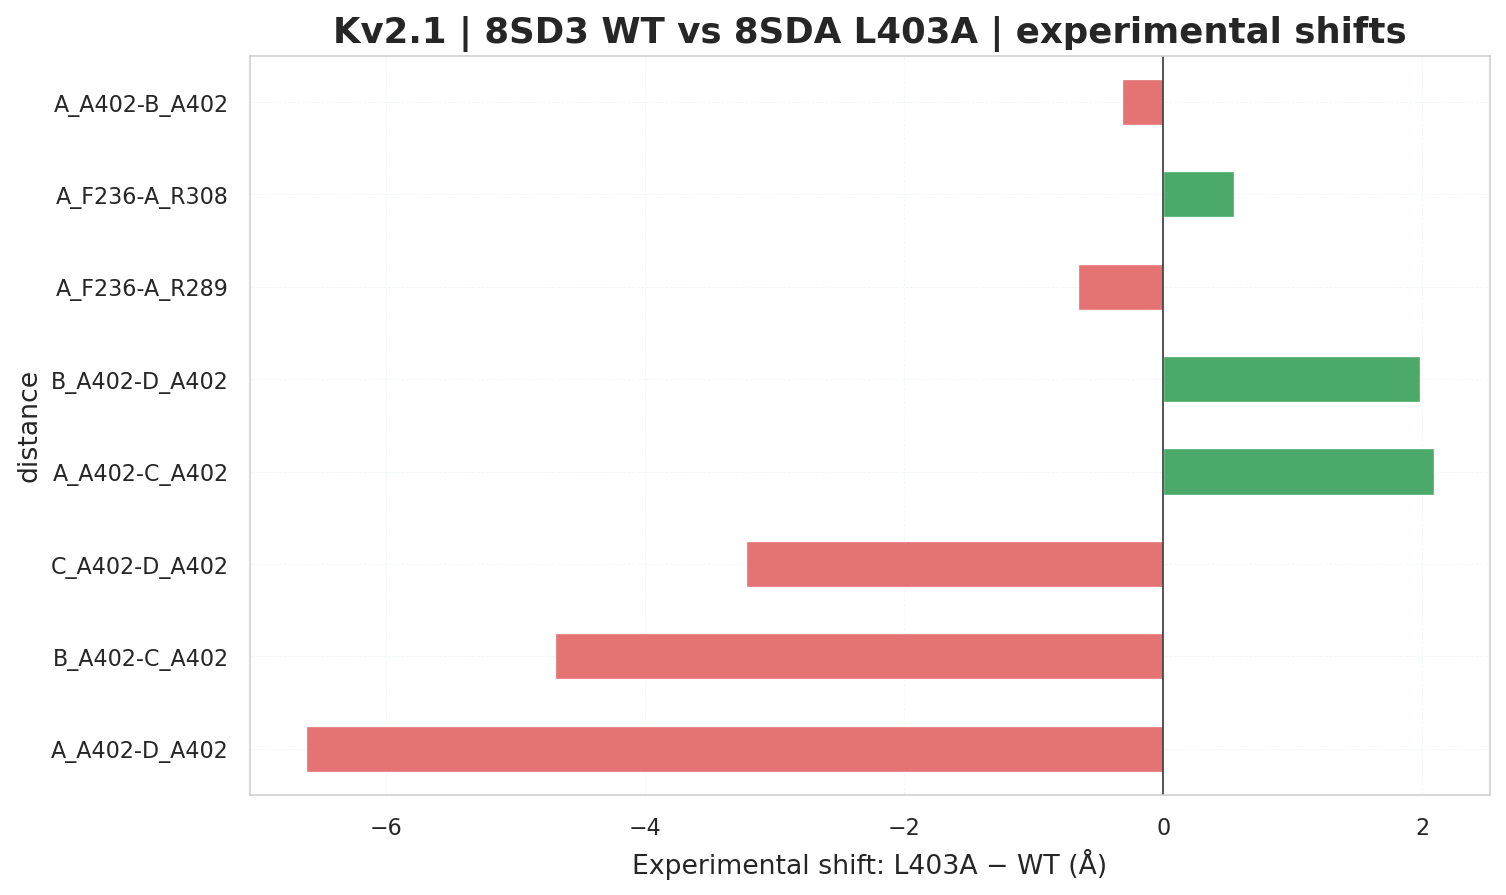

In [48]:
# Repeat the mutation-site comparison for vanilla ensembles.
print('Vanilla mutation-site distributions are included in the experimental comparison section below.')

# Rank the experimental WT -> L403A shifts (8SD3 versus 8SDA).
wt_exp = {"A_A402-B_A402":10.477,"A_A402-C_A402":10.465,"A_A402-D_A402":14.815,"B_A402-C_A402":14.808,"B_A402-D_A402":10.480,"C_A402-D_A402":10.470,"A_F236-A_R289":25.412,"A_F236-A_R308":13.004}
mut_exp = {"A_A402-B_A402":10.159,"A_A402-C_A402":12.553,"A_A402-D_A402":8.202,"B_A402-C_A402":10.117,"B_A402-D_A402":12.460,"C_A402-D_A402":7.248,"A_F236-A_R289":24.752,"A_F236-A_R308":13.550}
shift_table = pd.DataFrame({"distance":list(wt_exp), "WT_8SD3":list(wt_exp.values()), "L403A_8SDA":[mut_exp[k] for k in wt_exp]})
shift_table["shift_A"] = shift_table["L403A_8SDA"] - shift_table["WT_8SD3"]
shift_table["abs_shift_A"] = shift_table["shift_A"].abs()
shift_table = shift_table.sort_values("abs_shift_A", ascending=False)
display(shift_table)
ax=shift_table.plot.barh(x="distance", y="shift_A", color=["#E57373" if x<0 else "#4BAA6A" for x in shift_table["shift_A"]], legend=False, figsize=(10,6))
ax.axvline(0,color="#444444",linewidth=.8); ax.set_xlabel("Experimental shift: L403A − WT (Å)"); ax.set_title("Kv2.1 | 8SD3 WT vs 8SDA L403A | experimental shifts")


## Four-chain neighborhood shift analysis


In [49]:
## Four-subunit pore–voltage-sensor interface distances
# These are same-subunit contacts from the intracellular pore/S6-side K427, E423, and K420
# to voltage-sensor-side N179 and V182, repeated across chains A–D.
residue_pairs = [("LYS429","ASN181"),("LYS429","VAL184"),("GLU425","ASN181"),("GLU425","VAL184"),("LYS422","ASN181"),("LYS422","VAL184"),("VAL411","VAL400"),("VAL411","ILE403"),("VAL411","ALA404"),("VAL411","LEU405"),("VAL411","PRO408"),("VAL411","ILE409"),("PHE414","LEU401"),("PHE414","ILE409"),("PHE414","TYR418")]
one_letter = {'LYS':'K', 'ASN':'N', 'VAL':'V', 'GLU':'E', 'ILE':'I', 'ALA':'A', 'LEU':'L', 'PRO':'P', 'PHE':'F', 'TYR':'Y'}
chain_aliases={}
for chain in "ABCD":
    for r1,r2 in residue_pairs:
        n1=int(''.join(x for x in r1[1:] if x.isdigit()))-2; n2=int(''.join(x for x in r2[1:] if x.isdigit()))-2
        label=f"{one_letter[r1[:3]]}{n1}{chain}-{one_letter[r2[:3]]}{n2}{chain}"
        col=f"CA_CA_{chain}_{r1}_CA-{chain}_{r2}_CA"
        chain_aliases[label]=col
chain_aliases={a:c for a,c in chain_aliases.items() if all(c in df.columns for df in (df_wt_masked,df_l403a_masked,df_wt_vanilla,df_l403a_vanilla))}
print(f"Four-subunit pore–VSD interface distances available: {len(chain_aliases)}")
print(list(chain_aliases))
print('Pore–VSD distributions are plotted below only after the experimental overlays are available.')


Four-subunit pore–VSD interface distances available: 24
['K427A-N179A', 'K427A-V182A', 'E423A-N179A', 'E423A-V182A', 'K420A-N179A', 'K420A-V182A', 'K427B-N179B', 'K427B-V182B', 'E423B-N179B', 'E423B-V182B', 'K420B-N179B', 'K420B-V182B', 'K427C-N179C', 'K427C-V182C', 'E423C-N179C', 'E423C-V182C', 'K420C-N179C', 'K420C-V182C', 'K427D-N179D', 'K427D-V182D', 'E423D-N179D', 'E423D-V182D', 'K420D-N179D', 'K420D-V182D']
Pore–VSD distributions are plotted below only after the experimental overlays are available.


## Separate WT and L403A distributions


In [50]:
# Single-ensemble plots are intentionally omitted to avoid duplicating the experimental comparisons below.


## Direct WT and L403A comparison


## Coordinate-derived experimental distances


In [51]:
## Experimental distances for the plotted residue pairs
import math, re

def read_ca(path):
    out={}
    for line in open(path):
        if line.startswith("ATOM") and line[12:16].strip()=="CA":
            out[(line[21],int(line[22:26]))]=tuple(float(line[i:i+8]) for i in (30,38,46))
    return out

def experimental_for_aliases(alias_map, pdb_path, csv_minus_pdb=0):
    ca=read_ca(pdb_path); result={}; missing=[]
    for alias in alias_map:
        nums=[int(x) for x in re.findall(r"\d+", alias)]
        chains=[part[-1] for part in alias.split("-")[:2]]
        if len(nums)!=2 or len(chains)<2: missing.append(alias); continue
        a=ca.get((chains[0],nums[0]-csv_minus_pdb)); b=ca.get((chains[1],nums[1]-csv_minus_pdb))
        if a is None or b is None: missing.append(alias); continue
        result[alias]=[round(math.dist(a,b),3)]
    return result, missing

exp_all_wt, missing_wt = experimental_for_aliases(chain_aliases, "experimental/8SD3.pdb")
exp_all_l403a, missing_l403a = experimental_for_aliases(chain_aliases, "experimental/8SDA.pdb")
print("Calculated WT experimentals:", len(exp_all_wt), "missing:", missing_wt)
print("Calculated L403A experimentals:", len(exp_all_l403a), "missing:", missing_l403a)
# These dictionaries contain every plotted alias that has a valid PDB correspondence.


Calculated WT experimentals: 24 missing: []
Calculated L403A experimentals: 24 missing: []


## Experimental reference values


In [52]:
# CORRECTED experimental dictionary: only motif/ChimeraX-confirmed mappings; unresolved pairs omitted.
EXPERIMENTAL_NEIGHBORHOOD_CORRECTED = {
    'G425A-A181A': {"8SD3_WT": [16.651], "8SDA_L403A": [16.485]},
    'G425A-V184A': {"8SD3_WT": [17.189], "8SDA_L403A": [17.153]},
    'G425B-A181B': {"8SD3_WT": [16.652], "8SDA_L403A": [16.585]},
    'G425B-V184B': {"8SD3_WT": [17.189], "8SDA_L403A": [17.174]},
    'G425C-A181C': {"8SD3_WT": [16.652], "8SDA_L403A": [18.761]},
    'G425C-V184C': {"8SD3_WT": [17.189], "8SDA_L403A": [19.632]},
    'G425D-A181D': {"8SD3_WT": [16.651], "8SDA_L403A": [20.712]},
    'G425D-V184D': {"8SD3_WT": [17.189], "8SDA_L403A": [22.395]},
    'L422A-A181A': {"8SD3_WT": [20.782], "8SDA_L403A": [20.387]},
    'L422A-V184A': {"8SD3_WT": [20.596], "8SDA_L403A": [20.373]},
    'L422B-A181B': {"8SD3_WT": [20.783], "8SDA_L403A": [20.471]},
    'L422B-V184B': {"8SD3_WT": [20.597], "8SDA_L403A": [20.395]},
    'L422C-A181C': {"8SD3_WT": [20.782], "8SDA_L403A": [21.449]},
    'L422C-V184C': {"8SD3_WT": [20.597], "8SDA_L403A": [21.662]},
    'L422D-A181D': {"8SD3_WT": [20.782], "8SDA_L403A": [23.936]},
    'L422D-V184D': {"8SD3_WT": [20.597], "8SDA_L403A": [24.983]},
    'L429A-A181A': {"8SD3_WT": [10.444], "8SDA_L403A": [10.248]},
    'L429A-V184A': {"8SD3_WT": [15.136], "8SDA_L403A": [15.135]},
    'L429B-A181B': {"8SD3_WT": [10.443], "8SDA_L403A": [10.327]},
    'L429B-V184B': {"8SD3_WT": [15.135], "8SDA_L403A": [15.415]},
    'L429C-A181C': {"8SD3_WT": [10.444], "8SDA_L403A": [13.952]},
    'L429C-V184C': {"8SD3_WT": [15.136], "8SDA_L403A": [19.889]},
    'L429D-A181D': {"8SD3_WT": [10.444], "8SDA_L403A": [18.307]},
    'L429D-V184D': {"8SD3_WT": [15.136], "8SDA_L403A": [23.855]},
    'P414A-I409A': {"8SD3_WT": [8.637], "8SDA_L403A": [8.566]},
    'P414A-L401A': {"8SD3_WT": [20.968], "8SDA_L403A": [20.635]},
    'P414A-T418A': {"8SD3_WT": [5.971], "8SDA_L403A": [6.339]},
    'P414B-I409B': {"8SD3_WT": [8.637], "8SDA_L403A": [8.356]},
    'P414B-L401B': {"8SD3_WT": [20.967], "8SDA_L403A": [20.979]},
    'P414B-T418B': {"8SD3_WT": [5.972], "8SDA_L403A": [6.412]},
    'P414C-I409C': {"8SD3_WT": [8.637], "8SDA_L403A": [7.745]},
    'P414C-L401C': {"8SD3_WT": [20.967], "8SDA_L403A": [20.241]},
    'P414C-T418C': {"8SD3_WT": [5.971], "8SDA_L403A": [6.165]},
    'P414D-I409D': {"8SD3_WT": [8.637], "8SDA_L403A": [7.834]},
    'P414D-L401D': {"8SD3_WT": [20.968], "8SDA_L403A": [20.737]},
    'P414D-T418D': {"8SD3_WT": [5.97], "8SDA_L403A": [6.321]},
    'V411A-A404A': {"8SD3_WT": [11.084], "8SDA_L403A": [10.753]},
    'V411A-I403A': {"8SD3_WT": [12.718], "8SDA_L403A": [12.703]},
    'V411A-I409A': {"8SD3_WT": [5.438], "8SDA_L403A": [5.465]},
    'V411A-L405A': {"8SD3_WT": [11.462], "8SDA_L403A": [11.267]},
    'V411A-P408A': {"8SD3_WT": [4.918], "8SDA_L403A": [5.042]},
    'V411A-V400A': {"8SD3_WT": [16.501], "8SDA_L403A": [16.296]},
    'V411B-A404B': {"8SD3_WT": [11.085], "8SDA_L403A": [10.902]},
    'V411B-I403B': {"8SD3_WT": [12.719], "8SDA_L403A": [13.355]},
    'V411B-I409B': {"8SD3_WT": [5.438], "8SDA_L403A": [5.107]},
    'V411B-L405B': {"8SD3_WT": [11.462], "8SDA_L403A": [11.286]},
    'V411B-P408B': {"8SD3_WT": [4.918], "8SDA_L403A": [4.98]},
    'V411B-V400B': {"8SD3_WT": [16.501], "8SDA_L403A": [16.663]},
    'V411C-A404C': {"8SD3_WT": [11.084], "8SDA_L403A": [11.071]},
    'V411C-I403C': {"8SD3_WT": [12.718], "8SDA_L403A": [12.907]},
    'V411C-I409C': {"8SD3_WT": [5.438], "8SDA_L403A": [5.48]},
    'V411C-L405C': {"8SD3_WT": [11.462], "8SDA_L403A": [10.743]},
    'V411C-P408C': {"8SD3_WT": [4.919], "8SDA_L403A": [5.339]},
    'V411C-V400C': {"8SD3_WT": [16.502], "8SDA_L403A": [17.128]},
    'V411D-A404D': {"8SD3_WT": [11.085], "8SDA_L403A": [10.861]},
    'V411D-I403D': {"8SD3_WT": [12.719], "8SDA_L403A": [12.957]},
    'V411D-I409D': {"8SD3_WT": [5.438], "8SDA_L403A": [5.668]},
    'V411D-L405D': {"8SD3_WT": [11.462], "8SDA_L403A": [10.597]},
    'V411D-P408D': {"8SD3_WT": [4.918], "8SDA_L403A": [4.905]},
    'V411D-V400D': {"8SD3_WT": [16.502], "8SDA_L403A": [17.528]},
}
# Rebuild the plotting dictionary from coordinates using the current experimental-numbered aliases.
# This prevents stale model-numbered labels from silently dropping every experimental marker.
EXPERIMENTAL_NEIGHBORHOOD_CORRECTED = {
    alias: {'8SD3_WT': exp_all_wt[alias], '8SDA_L403A': exp_all_l403a[alias]}
    for alias in chain_aliases if alias in exp_all_wt and alias in exp_all_l403a
}
print("Coordinate-matched experimental aliases retained:", len(EXPERIMENTAL_NEIGHBORHOOD_CORRECTED))
print("Omitted aliases lack a resolved Cα atom in at least one experimental structure.")


Coordinate-matched experimental aliases retained: 24
Omitted aliases lack a resolved Cα atom in at least one experimental structure.


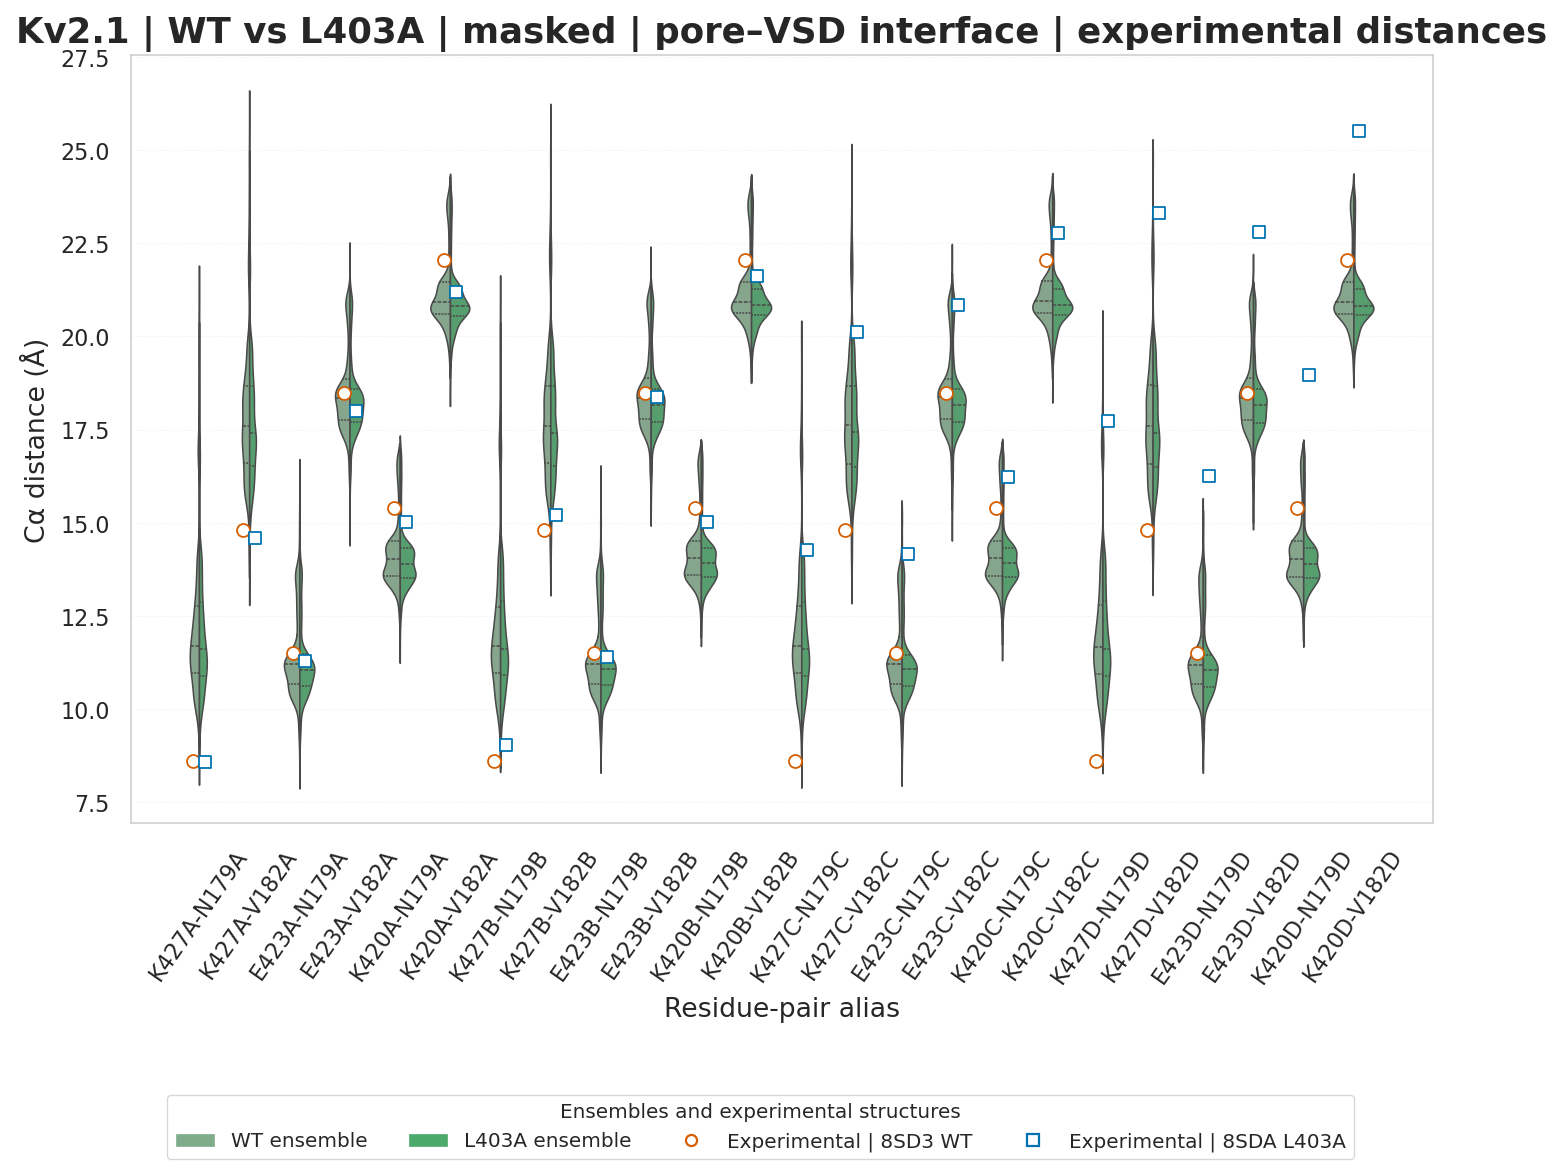

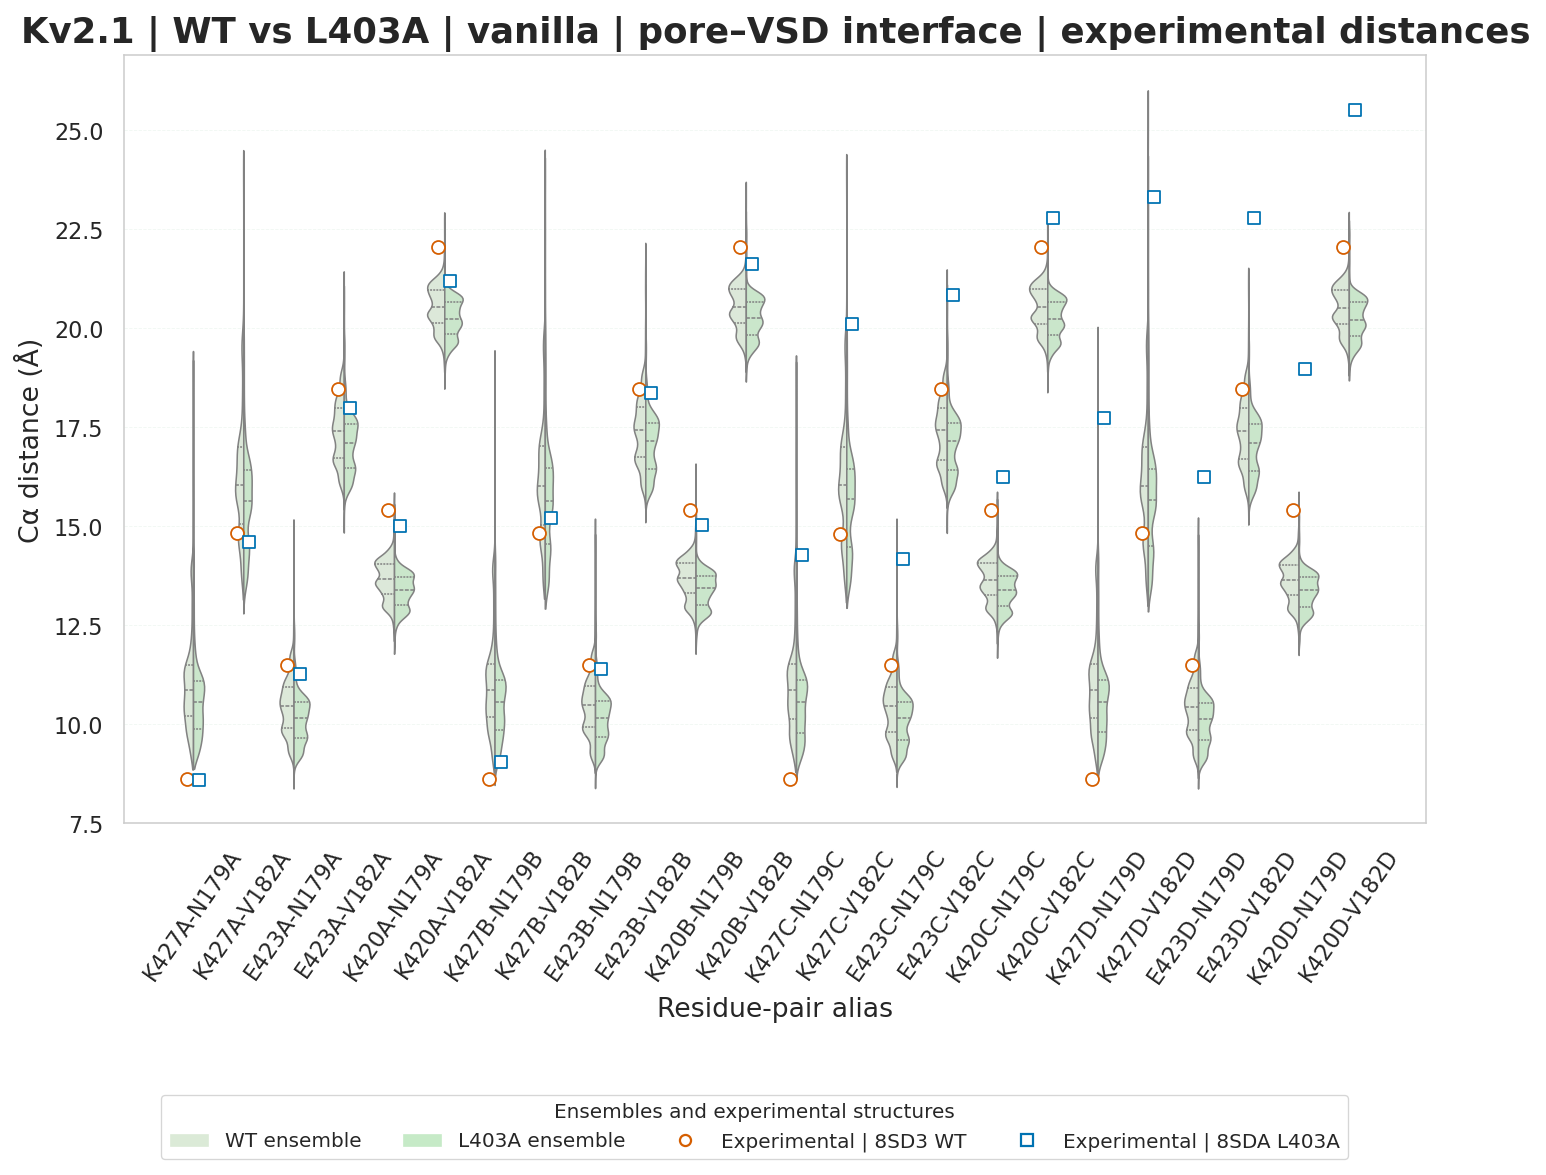

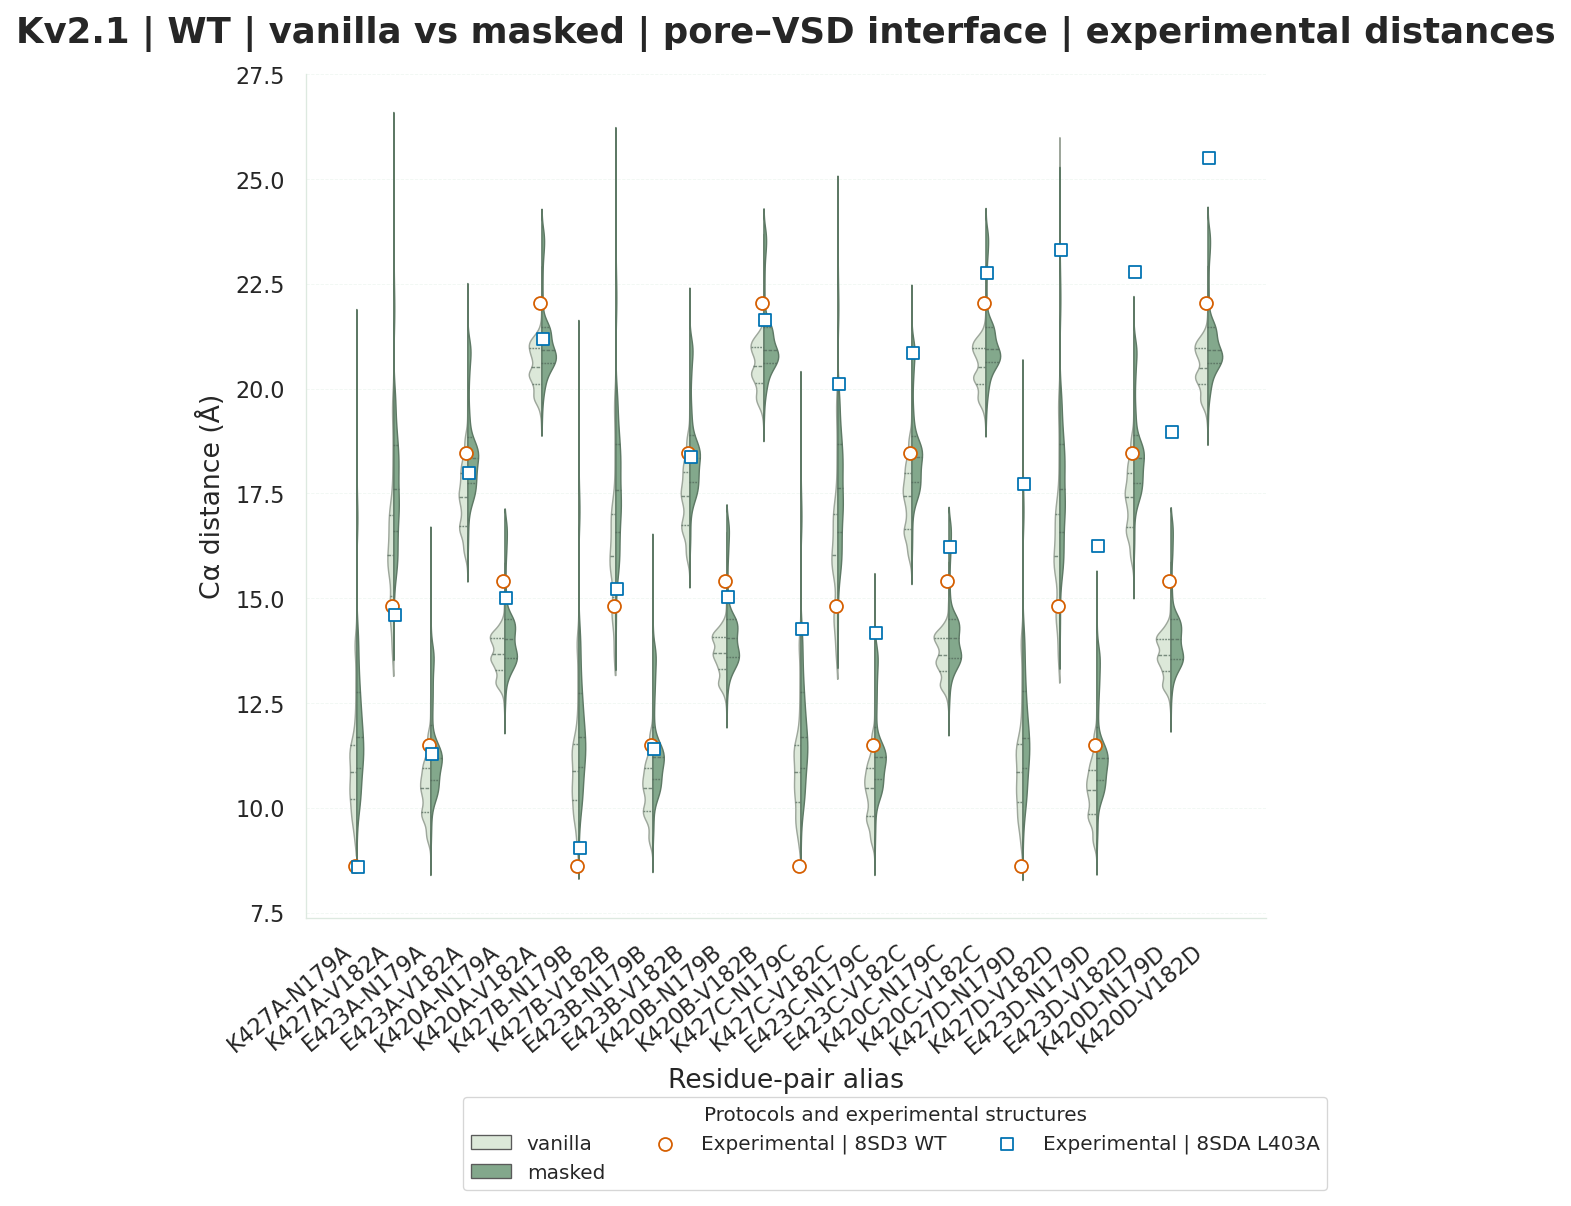

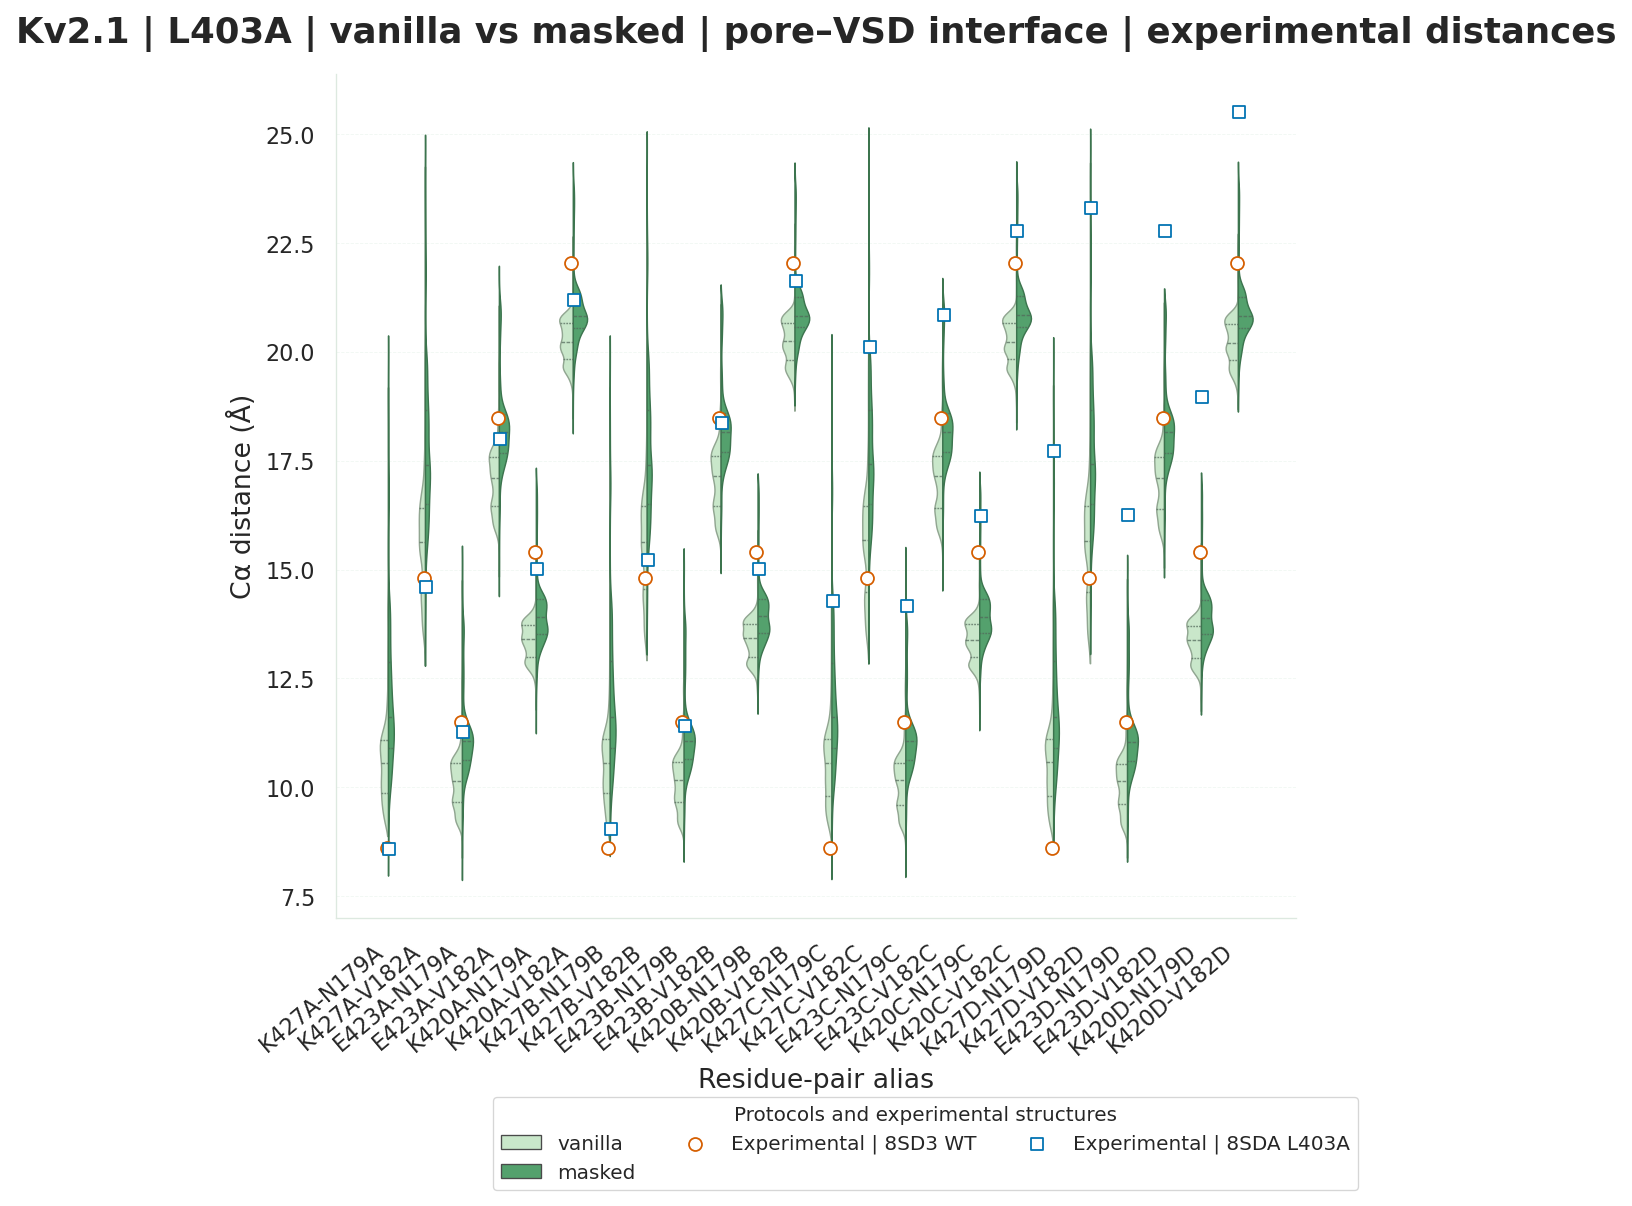

<Axes: title={'center': 'Kv2.1 | L403A | vanilla vs masked | pore–VSD interface | experimental distances'}, xlabel='Residue-pair alias', ylabel='Cα distance (Å)'>

In [53]:
# Split violins with the explicit WT/L403A experimental markers.
def split_violin_kv_with_experimentals(df_wt, df_mut, aliases, title, colors, exp_dict):
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    rows=[]
    for alias,col in aliases.items():
        for v in pd.to_numeric(df_wt[col],errors="coerce").dropna(): rows.append({"Distance":v,"Alias":alias,"Ensemble":"WT"})
        for v in pd.to_numeric(df_mut[col],errors="coerce").dropna(): rows.append({"Distance":v,"Alias":alias,"Ensemble":"L403A"})
    plot_df=pd.DataFrame(rows); fig,ax=plt.subplots(figsize=(10.5,8))
    sns.violinplot(data=plot_df,x="Alias",y="Distance",hue="Ensemble",split=True,inner="quartile",cut=0,linewidth=.7,palette={"WT":colors[0],"L403A":colors[1]},ax=ax)
    order=list(aliases); xpos={a:i for i,a in enumerate(order)}
    for alias in order:
        exp_key = alias if alias in exp_dict else None
        if exp_key is not None:
            ax.scatter(xpos[alias]-.12, exp_dict[exp_key]["8SD3_WT"][0], facecolors="white", edgecolors="#D55E00", marker="o", s=34, linewidths=.8, zorder=5)
            ax.scatter(xpos[alias]+.12, exp_dict[exp_key]["8SDA_L403A"][0], facecolors="white", edgecolors="#0072B2", marker="s", s=34, linewidths=.8, zorder=5)
    ax.set_title(title); ax.set_xlabel("Residue-pair alias"); ax.set_ylabel("Cα distance (Å)"); ax.tick_params(axis="x",rotation=55)
    legend_handles=[Patch(facecolor=colors[0],label="WT ensemble"),Patch(facecolor=colors[1],label="L403A ensemble"),Line2D([0],[0],marker="o",color="none",markerfacecolor="white",markeredgecolor="#D55E00",label="Experimental | 8SD3 WT",markersize=5),Line2D([0],[0],marker="s",color="none",markerfacecolor="white",markeredgecolor="#0072B2",label="Experimental | 8SDA L403A",markersize=5)]
    ax.get_legend().remove()
    fig.legend(handles=legend_handles,title="Ensembles and experimental structures",loc="lower center",bbox_to_anchor=(.5,.01),ncol=4,fontsize=9,title_fontsize=9,frameon=True)
    fig.subplots_adjust(bottom=.28); plt.show()

split_violin_kv_with_experimentals(df_wt_masked,df_l403a_masked,chain_aliases,"Kv2.1 | WT vs L403A | masked | pore–VSD interface | experimental distances",[KV21_PALETTE["WT_HM"],KV21_PALETTE["L403A_HM"]],EXPERIMENTAL_NEIGHBORHOOD_CORRECTED)
split_violin_kv_with_experimentals(df_wt_vanilla,df_l403a_vanilla,chain_aliases,"Kv2.1 | WT vs L403A | vanilla | pore–VSD interface | experimental distances",[KV21_PALETTE["WT_VAN"],KV21_PALETTE["L403A_VAN"]],EXPERIMENTAL_NEIGHBORHOOD_CORRECTED)

# The complementary comparison asks how masking changes each construct.
protocol_exp_distances = [
    {alias: values['8SD3_WT'] for alias, values in EXPERIMENTAL_NEIGHBORHOOD_CORRECTED.items()},
    {alias: values['8SDA_L403A'] for alias, values in EXPERIMENTAL_NEIGHBORHOOD_CORRECTED.items()},
]
protocol_exp_labels = ['Experimental | 8SD3 WT', 'Experimental | 8SDA L403A']
protocol_exp_colors = ['#D55E00', '#0072B2']
plot_protocol_split_with_experimentals(
    df_wt_vanilla, df_wt_masked, chain_aliases,
    title='Kv2.1 | WT | vanilla vs masked | pore–VSD interface | experimental distances',
    colors=[KV21_PALETTE['WT_VAN'], KV21_PALETTE['WT_HM']],
    exp_distances_list=protocol_exp_distances, dataset_labels=protocol_exp_labels, pdb_colors=protocol_exp_colors,
)
plot_protocol_split_with_experimentals(
    df_l403a_vanilla, df_l403a_masked, chain_aliases,
    title='Kv2.1 | L403A | vanilla vs masked | pore–VSD interface | experimental distances',
    colors=[KV21_PALETTE['L403A_VAN'], KV21_PALETTE['L403A_HM']],
    exp_distances_list=protocol_exp_distances, dataset_labels=protocol_exp_labels, pdb_colors=protocol_exp_colors,
)


## Experimental reference set used in the figures


## Top mutation-induced shifts


,distance,WT_median_A,L403A_median_A,median_shift_A
1,K427A-V182A,17.60,17.40,-0.20
13,K427C-V182C,17.62,17.43,-0.19
15,E423C-V182C,18.36,18.17,-0.19
19,K427D-V182D,17.60,17.42,-0.18
3,E423A-V182A,18.34,18.16,-0.18
21,E423D-V182D,18.34,18.16,-0.18
7,K427B-V182B,17.59,17.41,-0.18
9,E423B-V182B,18.35,18.17,-0.18
14,E423C-N179C,11.22,11.07,-0.15
8,E423B-N179B,11.21,11.07,-0.14


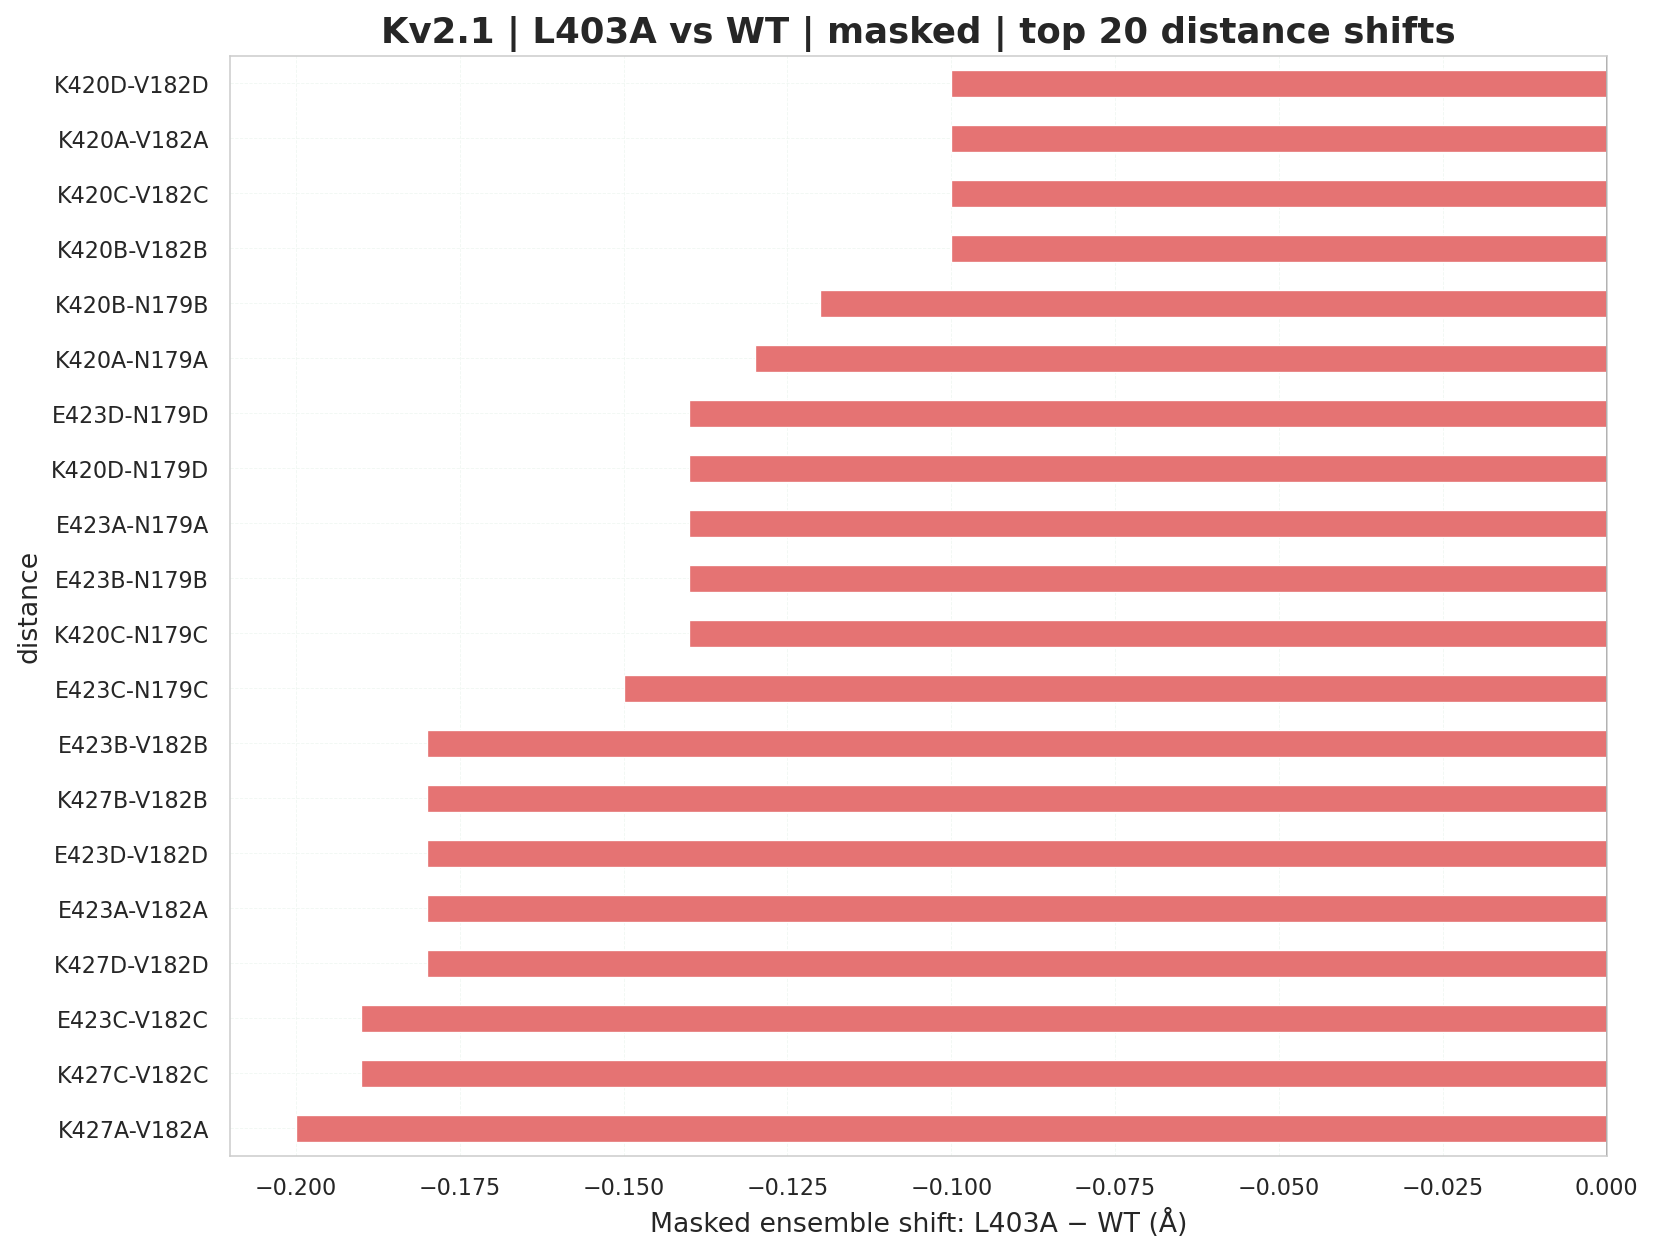

In [54]:
## Largest WT → L403A shifts (top 20)
shift_rows=[]
for alias,col in chain_aliases.items():
    wt=pd.to_numeric(df_wt_masked[col],errors="coerce").dropna().median()
    mut=pd.to_numeric(df_l403a_masked[col],errors="coerce").dropna().median()
    shift_rows.append({"distance":alias,"WT_median_A":wt,"L403A_median_A":mut,"median_shift_A":mut-wt})
shift_table=pd.DataFrame(shift_rows).dropna().sort_values("median_shift_A",key=lambda x:x.abs(),ascending=False).head(20)
display(shift_table)
ax=shift_table.sort_values("median_shift_A").plot.barh(x="distance",y="median_shift_A",color=["#176B3A" if x>0 else "#E57373" for x in shift_table.sort_values("median_shift_A")["median_shift_A"]],legend=False,figsize=(10.5,8))
ax.axvline(0,color="#444444",linewidth=.8); ax.set_xlabel("Masked ensemble shift: L403A − WT (Å)"); ax.set_title("Kv2.1 | L403A vs WT | masked | top 20 distance shifts"); plt.tight_layout(); plt.show()


## Experimental shift overview


,Alias,Distance,Structure
0,K427A-N179A,8.616,8SD3 | WT
1,K427A-N179A,8.589,8SDA | L403A
2,K427A-V182A,14.816,8SD3 | WT
3,K427A-V182A,14.596,8SDA | L403A
4,E423A-N179A,11.508,8SD3 | WT
5,E423A-N179A,11.280,8SDA | L403A
6,E423A-V182A,18.473,8SD3 | WT
7,E423A-V182A,17.993,8SDA | L403A
8,K420A-N179A,15.407,8SD3 | WT
9,K420A-N179A,15.010,8SDA | L403A


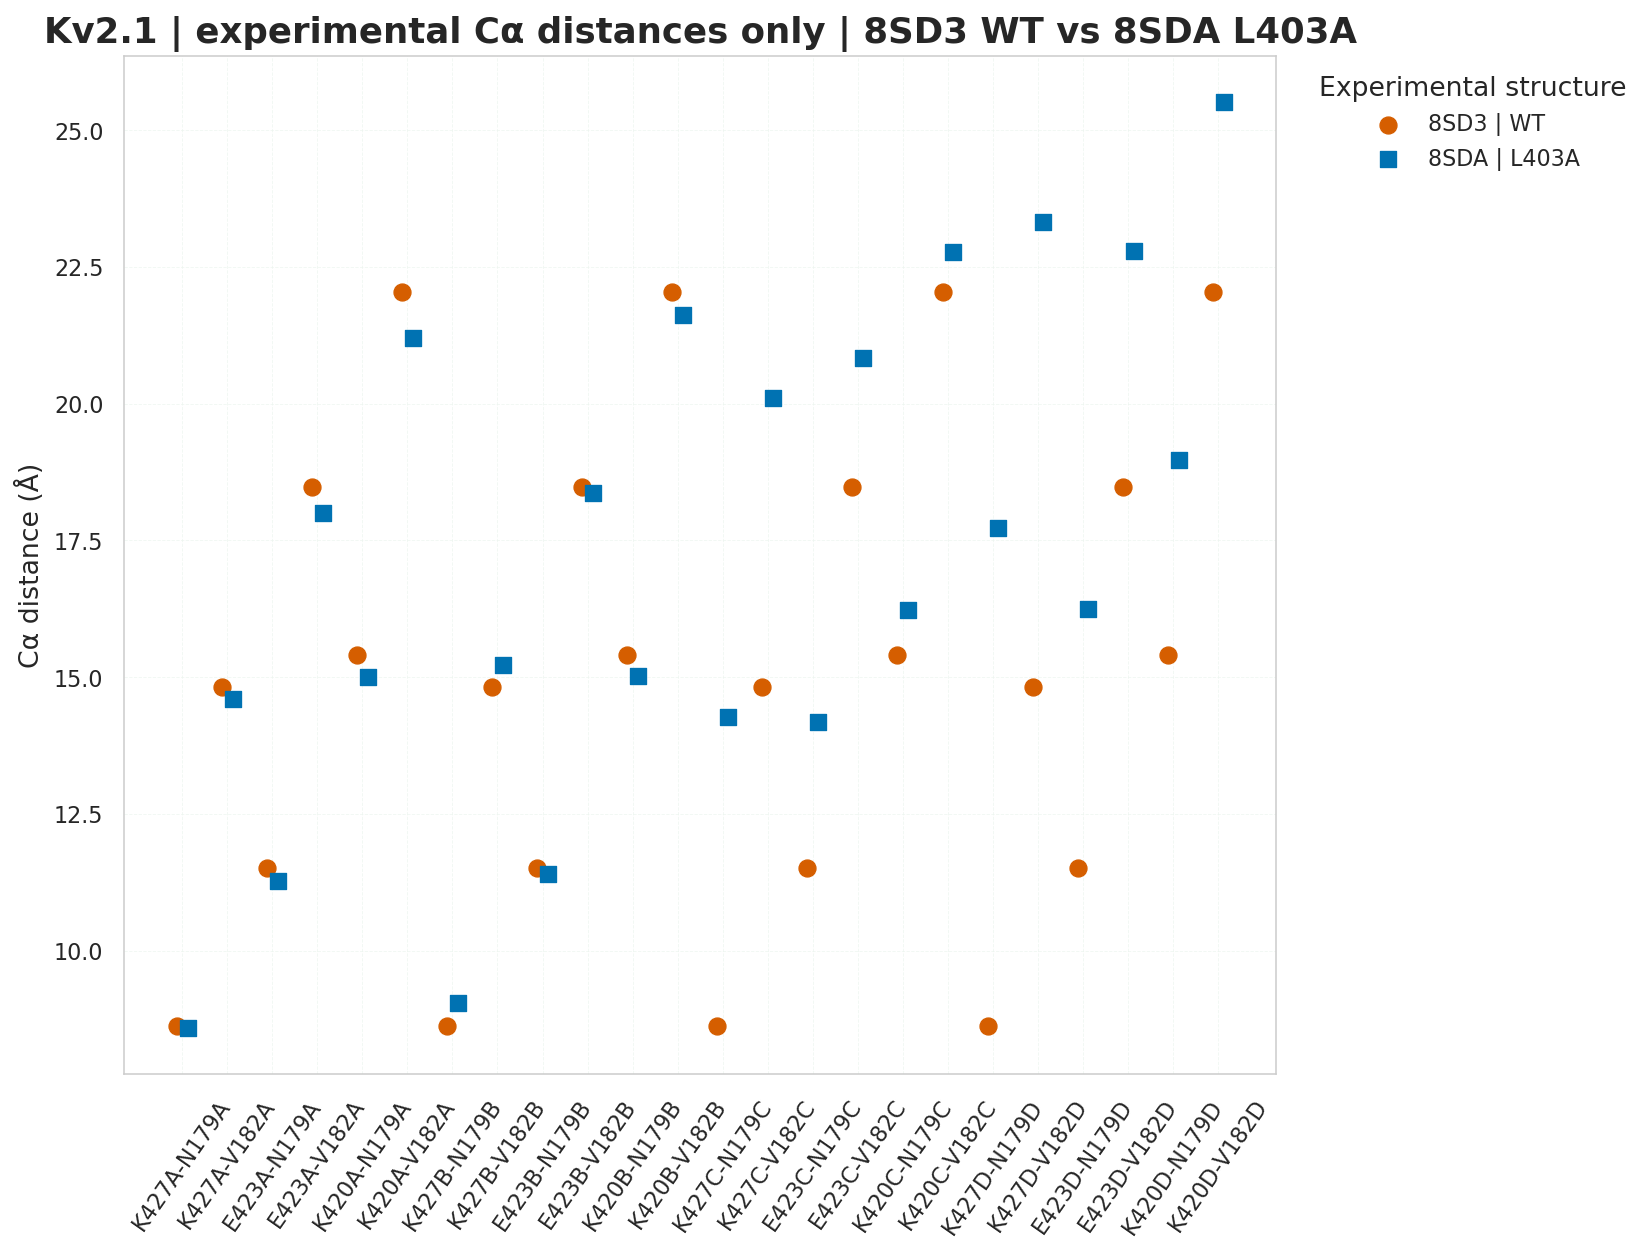

In [55]:
## Experimental-only audit panel
_exp_rows=[]
for alias in chain_aliases:
    key=alias if alias in EXPERIMENTAL_NEIGHBORHOOD_CORRECTED else None
    if key: _exp_rows += [{"Alias":alias,"Distance":EXPERIMENTAL_NEIGHBORHOOD_CORRECTED[key]["8SD3_WT"][0],"Structure":"8SD3 | WT"},{"Alias":alias,"Distance":EXPERIMENTAL_NEIGHBORHOOD_CORRECTED[key]["8SDA_L403A"][0],"Structure":"8SDA | L403A"}]
_exp_df=pd.DataFrame(_exp_rows, columns=['Alias','Distance','Structure']); display(_exp_df)
if _exp_df.empty:
    raise ValueError('No experimental aliases matched. Rerun the coordinate-calculation and experimental-dictionary cells above.')
fig,ax=plt.subplots(figsize=(10.5,8))
for i, alias in enumerate(chain_aliases):
    part=_exp_df[_exp_df['Alias'].eq(alias)]
    for offset,structure,color,marker in [(-.12,'8SD3 | WT','#D55E00','o'),(.12,'8SDA | L403A','#0072B2','s')]:
        values=part.loc[part['Structure'].eq(structure),'Distance']
        ax.scatter([i+offset]*len(values),values,color=color,marker=marker,s=58,label=structure if i==0 else None)
ax.set_xticks(range(len(chain_aliases)),list(chain_aliases),rotation=55); ax.set_title("Kv2.1 | experimental Cα distances only | 8SD3 WT vs 8SDA L403A"); ax.set_ylabel('Cα distance (Å)'); ax.legend(title="Experimental structure",bbox_to_anchor=(1.02,1),loc="upper left"); fig.tight_layout(); plt.show()

## Contacts altered by L403A (model/CSV L405A)
from shared.mutation_contact_analysis import plot_mutation_contacts, plot_selected_contact_distributions
l403a_contact_table, _ = plot_mutation_contacts(
    {'vanilla': (df_wt_vanilla, df_l403a_vanilla), 'masked': (df_wt_masked, df_l403a_masked)},
    'LEU405A', 'ALA405A', 'L403A',
    {'vanilla': KV21_PALETTE['L403A_VAN'], 'masked': KV21_PALETTE['L403A_HM']}, channel='Kv2.1',
)
display(l403a_contact_table.head(15).round(3))
l403a_top_partners = list(dict.fromkeys(l403a_contact_table['Partner']))[:3]
plot_selected_contact_distributions(
    {'vanilla': (df_wt_vanilla, df_l403a_vanilla), 'masked': (df_wt_masked, df_l403a_masked)},
    'LEU405A', 'ALA405A', 'L403A', l403a_top_partners,
    {'vanilla': (KV21_PALETTE['WT_VAN'], KV21_PALETTE['L403A_VAN']), 'masked': (KV21_PALETTE['WT_HM'], KV21_PALETTE['L403A_HM'])}, channel='Kv2.1',
)
